In [53]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
train_data = pd.read_csv("C:/Users/vaici/Documents/Akvile_python/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
test_data = pd.read_csv("C:/Users/vaici/Documents/Akvile_python/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [12]:
# Can we predict a passenger's Fare based on their Pclass, Age, and number of family members aboard (SibSp + Parch)?


--- Data types ---
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

--- Missing values ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Numeric summary ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.12

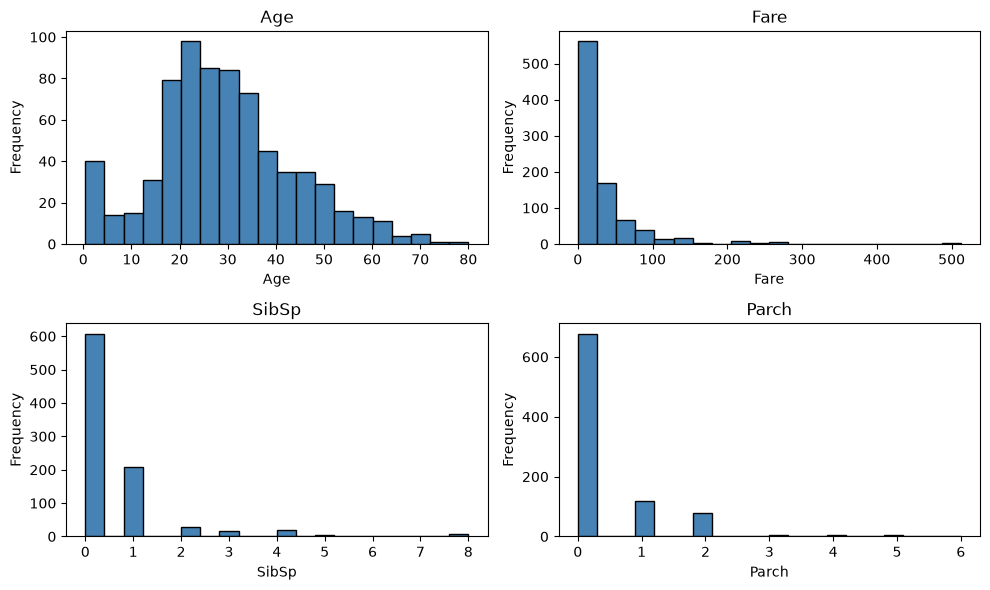

In [13]:
# EXPLORE DATA

print("\n--- Data types ---")
print(train_data.dtypes)
 
print("\n--- Missing values ---")
print(train_data.isnull().sum())
 
print("\n--- Numeric summary ---")
print(train_data.describe())
 
print("\n--- Categorical value counts ---")
for col in ["Sex", "Embarked", "Pclass"]:
    print(f"\n{col}:\n{train_data[col].value_counts(dropna=False)}")

# Histograms for numeric columns
num_cols = ["Age", "Fare", "SibSp", "Parch"]
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
 
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(train_data[col].dropna(), bins=20, color="steelblue", edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
 
plt.tight_layout()
plt.savefig("histograms.png")
plt.show()


--- Correlation matrix ---
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


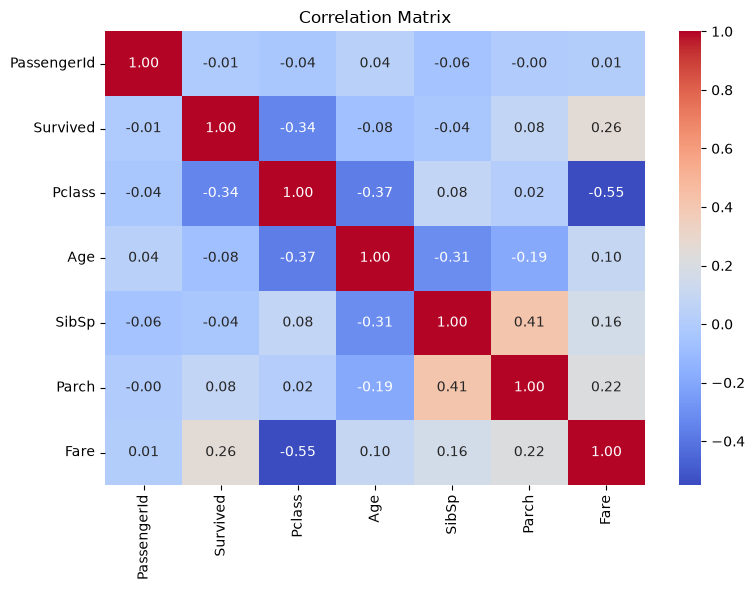


--- Avg Fare by Pclass ---
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

--- Avg Age by Survived ---
Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64


In [14]:
# CHECK RELATIONSHIPS

numeric_cols = train_data.select_dtypes(include=[np.number]).columns
corr = train_data[numeric_cols].corr()
print("\n--- Correlation matrix ---")
print(corr)
 
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()
 
# Grouped comparison example: average Fare by Pclass
print("\n--- Avg Fare by Pclass ---")
print(train_data.groupby("Pclass")["Fare"].mean())
 
print("\n--- Avg Age by Survived ---")
print(train_data.groupby("Survived")["Age"].mean())

In [15]:
# Based on Correlation Matrix, PClass is a strong candidate as feature for predicting Fare
# Second candidate - Parch

In [16]:
# CLEAN TRAIN DATA

train_clean = train_data.copy()
 
# Age: impute with median
train_clean["Age"] = train_clean["Age"].fillna(train_clean["Age"].median())
 
# Embarked: impute with mode (most frequent port)
train_clean["Embarked"] = train_clean["Embarked"].fillna(train_clean["Embarked"].mode()[0])
 
# Cabin: too many missing values -> drop column
train_clean = train_clean.drop(columns=["Cabin"])
 
# Drop columns unlikely to be useful as-is
train_clean = train_clean.drop(columns=["PassengerId", "Name", "Ticket"])

# Fill missing (blank/NaN) Fare values with the training median
fare_median = train_clean["Fare"].median()
train_clean["Fare"] = train_clean["Fare"].fillna(fare_median)
 
# Replace 0 Fare values with the training median
# A fare of 0 is likely missing/invalid data, not a real free ticket
train_clean["Fare"] = np.where(train_clean["Fare"] == 0, fare_median, train_clean["Fare"])
 
# Cap extreme Fare outliers at the 99th percentile
# The fare value that 99% of passengers paid at or below
fare_cap = train_clean["Fare"].quantile(0.99)
# Someone who paid way more than almost everyone else - replace with fare cap, else keep the original fare
train_clean["Fare"] = np.where(train_clean["Fare"] > fare_cap, fare_cap, train_clean["Fare"])
 
print("\n--- Missing values after cleaning ---")
print(train_clean.isnull().sum())


--- Missing values after cleaning ---
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [17]:
# ENCODE CATEGORICAL VALUES - TRAIN DATA

# Sex: binary encoding
train_clean["Sex"] = train_clean["Sex"].map({"male": 0, "female": 1})
 
# Pclass, Embarked: one-hot encoding (drop_first avoids multicollinearity)
# Those dropped categories become the "baseline" or "reference" group.
# If a passenger has Pclass_2 = 0 and Pclass_3 = 0, the model already knows they must be in Pclass 1
# no extra column needed to say so.
# Each category becomes its own 0/1 column, one category is left out as the "default" baseline,
# and the model interprets other categories relative to that baseline.
train_clean = pd.get_dummies(train_clean, columns=["Pclass", "Embarked"], drop_first=True)
 
print("\n--- Final cleaned & encoded dataset ---")
print(train_clean.head())
print("Shape:", train_clean.shape)
 
train_clean.to_csv("titanic_cleaned.csv", index=False)
print("\nSaved cleaned dataset to titanic_cleaned.csv")


--- Final cleaned & encoded dataset ---
   Survived  Sex   Age  SibSp  Parch     Fare  Pclass_2  Pclass_3  Embarked_Q  \
0         0    0  22.0      1      0   7.2500     False      True       False   
1         1    1  38.0      1      0  71.2833     False     False       False   
2         1    1  26.0      0      0   7.9250     False      True       False   
3         1    1  35.0      1      0  53.1000     False     False       False   
4         0    0  35.0      0      0   8.0500     False      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  
Shape: (891, 10)

Saved cleaned dataset to titanic_cleaned.csv


In [18]:
# Because Kaggle provides 2 datasets - one for training and one for testing, there is no need to split the dataset
# If the split is needed, uncomment this section
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# random_state=42 - to get the same split of data into training and testing groups, every single time (like a recipe for shuffling)

In [42]:
# SELECT FEATURES AND TARGET - TRAIN DATA
# Keep only the columns we need: Pclass (feature) and Fare (target)
# Note: after one-hot encoding, Pclass_2 and Pclass_3 represent Pclass
# (Pclass_1 is the dropped baseline category)
# pclass_cols = [col for col in train_clean.columns if col.startswith("Pclass")]
feature_cols = [col for col in train_clean.columns
                if col.startswith("Pclass") or col.startswith("Embarked")] + ["SibSp", "Parch"]
 
x_train = train_clean[feature_cols]
y_train = train_clean["Fare"]

In [43]:
x_train
y_train

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [47]:
# FIT THE MODEL
# It looks at your training data — the features (X_train, like Pclass) and the actual answers (y_train, the real Fare values)
# and figures out the best straight line that connects them.
# In practice, it's calculating the intercept and coefficients: the numbers that, when plugged into the line equation,
# make the predictions as close as possible to the real Fare values in your training data.
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-56.36,-65.61, -7.98,-10.88, 6.11, 10.41]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Pclass_2','Pclass_3','Embarked_Q','Embarked_S','SibSp','Parch']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,80.43
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [48]:
# Check intercept (baseline Fare prediction when all features are 0) and
# coefficients (one per feature, showing how much Fare is predicted to change for each Pclass_* category relative to that baseline)
print("Intercept:", model.intercept_)
 
print("\nCoefficients:")
for feature, coef in zip(x_train.columns, model.coef_):
    print(f"  {feature}: {coef}")
    
# Intercept - the model predicts that a 1st class passenger pays around 80.43 on average
# Coefficient for Pclass_2: -56.36
# This means: compared to Pclass_1, being in Pclass_2 is associated with paying 59.45 less.
# Coefficient for Pclass_3: -65.61
# Compared to Pclass_1, being in Pclass_3 is associated with paying 66.44 less.

Intercept: 80.42802629616432

Coefficients:
  Pclass_2: -56.35768236793148
  Pclass_3: -65.61219133698415
  Embarked_Q: -7.981703368324155
  Embarked_S: -10.878058382550861
  SibSp: 6.114014634998732
  Parch: 10.405828843693033


In [49]:
# CLEAN TEST DATA

test_clean = test_data.copy()
 
# Age: impute with median
test_clean["Age"] = test_clean["Age"].fillna(test_clean["Age"].median())
 
# Embarked: impute with mode (most frequent port)
test_clean["Embarked"] = test_clean["Embarked"].fillna(test_clean["Embarked"].mode()[0])
 
# Cabin: too many missing values -> drop column
test_clean = test_clean.drop(columns=["Cabin"])
 
# Drop columns unlikely to be useful as-is
test_clean = test_clean.drop(columns=["PassengerId", "Name", "Ticket"])

# Fill missing (blank/NaN) Fare values with the training median
fare_median = train_clean["Fare"].median()
test_clean["Fare"] = test_clean["Fare"].fillna(fare_median)
 
# Replace 0 Fare values with the training median
# A fare of 0 is likely missing/invalid data, not a real free ticket
test_clean["Fare"] = np.where(test_clean["Fare"] == 0, fare_median, test_clean["Fare"])
 
# Cap extreme Fare outliers at the 99th percentile
# The fare value that 99% of passengers paid at or below
fare_cap = test_clean["Fare"].quantile(0.99)
# Someone who paid way more than almost everyone else - replace with fare cap, else keep the original fare
test_clean["Fare"] = np.where(test_clean["Fare"] > fare_cap, fare_cap, test_clean["Fare"])
 
print("\n--- Missing values after cleaning ---")
print(test_clean.isnull().sum())


--- Missing values after cleaning ---
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [50]:
# ENCODE CATEGORICAL VALUES - TEST DATA

# Sex: binary encoding
test_clean["Sex"] = test_clean["Sex"].map({"male": 0, "female": 1})
 
# Pclass, Embarked: one-hot encoding (drop_first avoids multicollinearity)
# Those dropped categories become the "baseline" or "reference" group.
# If a passenger has Pclass_2 = 0 and Pclass_3 = 0, the model already knows they must be in Pclass 1
# no extra column needed to say so.
# Each category becomes its own 0/1 column, one category is left out as the "default" baseline,
# and the model interprets other categories relative to that baseline.
test_clean = pd.get_dummies(test_clean, columns=["Pclass", "Embarked"], drop_first=True)
 
print("\n--- Final cleaned & encoded dataset ---")
print(test_clean.head())
print("Shape:", test_clean.shape)
 
test_clean.to_csv("titanic_cleaned.csv", index=False)
print("\nSaved cleaned dataset to titanic_cleaned.csv")


--- Final cleaned & encoded dataset ---
   Sex   Age  SibSp  Parch     Fare  Pclass_2  Pclass_3  Embarked_Q  \
0    0  34.5      0      0   7.8292     False      True        True   
1    1  47.0      1      0   7.0000     False      True       False   
2    0  62.0      0      0   9.6875      True     False        True   
3    0  27.0      0      0   8.6625     False      True       False   
4    1  22.0      1      1  12.2875     False      True       False   

   Embarked_S  
0       False  
1        True  
2       False  
3        True  
4        True  
Shape: (418, 9)

Saved cleaned dataset to titanic_cleaned.csv


In [51]:
# MAKE PREDICTIONS

# Prepare test features
# Use the same Pclass_* columns as in training
# pclass_cols = [col for col in x_train.columns]
feature_cols = [col for col in test_clean.columns
                if col.startswith("Pclass") or col.startswith("Embarked")] + ["SibSp", "Parch"]
x_test = test_clean[feature_cols]
y_test = test_clean["Fare"]

y_pred = model.predict(x_test)

In [52]:
# EVALUATE PERFORMANCE

# RMSE — average prediction error, in the same units as Fare (lower = better)
# R² — how much of the variation in Fare the model explains, from 0 to 1 (higher = better)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
 
print("RMSE:", rmse)
print("R^2:", r2)

# On average, your model's Fare predictions are off by about 36.88
# Intercept was ~80 (average 1st class fare), and 3rd class averaged closer to ~14.
# An average error of ~40 is actually quite large relative to those numbers — meaning predictions can be pretty far off, 
# especially for the cheaper classes.
# R^2 means model explains about 49% of the variation in Fare.

RMSE: 36.880978062198736
R^2: 0.4935001273167118


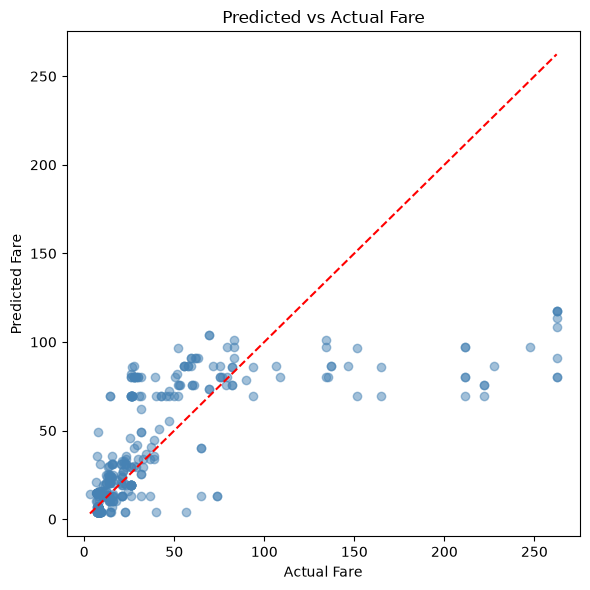

In [54]:
# PREDICTED VS ACTUALS

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue")
 
# Diagonal reference line: perfect predictions would fall exactly on this line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
 
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Predicted vs Actual Fare")
plt.tight_layout()
plt.savefig("predicted_vs_actual.png")
plt.show()

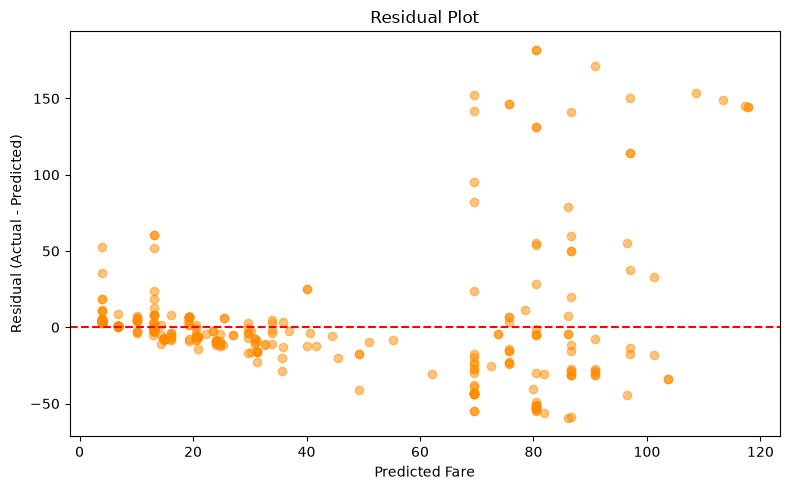

In [55]:
# RESIDUAL PLOT

residuals = y_test - y_pred
 
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color="darkorange")
plt.axhline(0, color="red", linestyle="--")
 
plt.xlabel("Predicted Fare")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig("residual_plot.png")
plt.show()